<h2 style="color: #e3b6ffff;">
<strong> Modelo ARIMA para predecir temperaturas</strong>
</h2>


Samantha Sánchez Tinoco

---------------------------------------------------------------------

<h3 style="color: #eed2ffff;">
<strong>Parte 1: Desarrollo Teórico del Modelo ARIMA (2,1,2)
</h3>


### Forma Canónica de un Modelo ARIMA (p,d,q)

$$
\phi(B)(1 - B)^d y_t = \theta(B)\varepsilon_t
$$

### Para un modelo ARIMA (2, 1, 2)

- $p = 2$
- $d = 1$
- $q = 2$

Entonces:

$$
(1 - \phi_1 B - \phi_2 B^2)(1 - B)y_t
=
(1 + \theta_1 B + \theta_2 B^2)\varepsilon_t
$$

Primero se aplica la diferencia de primer orden:

$$
(1 - B)y_t = y_t - y_{t-1}
$$

Después se define como:

$$
w_t = y_t - y_{t-1}
$$

Y lo sustituimos en el modelo

$$
(1 - \phi_1 B - \phi_2 B^2) w_t
=
(1 + \theta_1 B + \theta_2 B^2)\varepsilon_t
$$


Ahora expandemos:

$$
w_t - \phi_1 w_{t-1} - \phi_2 w_{t-2}
=
\varepsilon_t + \theta_1 \varepsilon_{t-1} + \theta_2 \varepsilon_{t-2}
$$

Y despejamos $w_t$:

$$
w_t =
\phi_1 w_{t-1}
+ \phi_2 w_{t-2}
+ \varepsilon_t
+ \theta_1 \varepsilon_{t-1}
+ \theta_2 \varepsilon_{t-2}
$$

Para reemplazar de nuevo $w_t = y_t - y_{t-1}$:

$$
y_t - y_{t-1} =
\phi_1 (y_{t-1} - y_{t-2})
+ \phi_2 (y_{t-2} - y_{t-3})
+ \varepsilon_t
+ \theta_1 \varepsilon_{t-1}
+ \theta_2 \varepsilon_{t-2}
$$

### Interpretación del Modelo

El modelo ARIMA (2, 1, 2):

- Aplica una diferenciación de primer orden ($d=1$) para convertir una serie no estacionaria en estacionaria.
- También incluye dos términos autoregresivos ($p=2$), para tener dependencia de los dos periodos anteriores.
- Incluye dos términos de medias móviles ($q=2$), para capturar el efecto de eventos pasados.
- Y modela tanto continuidad temporal como los efectos acumulados del error.


### Conclusión

El modelo ARIMA(2,1,2):

- Nos permite modelar series inicialmente no estacionarias.
- Captura cambios y dinámicas de corto plazo en los datos.
- Integra memoria  efectos de ruido pasado.


--------------------------------------------

<h3 style="color: #eed2ffff;">
<strong>Parte 2: Modelado con 3 librerías diferentes
</h3>

In [5]:
import pandas as pd
import numpy as np
from statsmodels.tsa.arima.model import ARIMA
import pmdarima as pm
from arch.univariate import ARX, ARIMA as ARCH_ARIMA
from sklearn.metrics import mean_squared_error
import plotly.graph_objects as go

ImportError: cannot import name 'ARIMA' from 'arch.univariate' (c:\Users\samys\miniconda3\envs\ModelosLineales\Lib\site-packages\arch\univariate\__init__.py)

In [2]:
df = pd.read_csv("../Datasets/rainfall.csv", parse_dates=['datetime'], dayfirst=True)
df.set_index('datetime', inplace=True)
df = df.asfreq('D')  # Asegurar frecuencia diaria


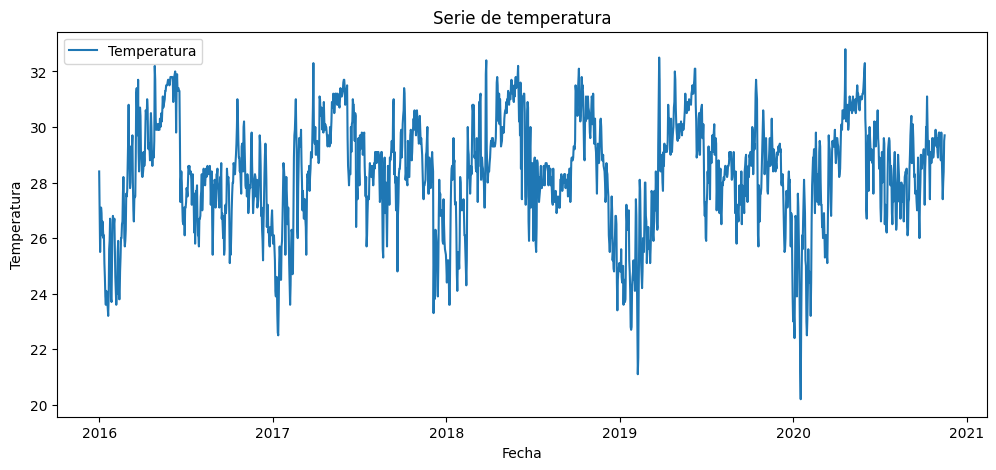

In [3]:
plt.figure(figsize=(12,5))
plt.plot(df['temp'], label='Temperatura')
plt.title('Serie de temperatura')
plt.xlabel('Fecha')
plt.ylabel('Temperatura')
plt.legend()
plt.show()

In [4]:
# Prueba ADF
result = adfuller(df['temp'])
print("ADF Statistic:", result[0])
print("p-value:", result[1])
if result[1] > 0.05:
    print("La serie no es estacionaria :(")
    series = df['temp'].diff().dropna()
else:
    print("La serie es estacionaria :)")
    series = df['temp']


ADF Statistic: -4.457682107545241
p-value: 0.0002343183173294433
La serie es estacionaria :)


In [5]:
# Train test split
train_size = int(len(series)*0.8)
train = series[:train_size].copy()
train.name = 'temp'
test = series[train_size:].copy()
test.name = 'temp'

#### Modelo con statsmodel

In [24]:
arima_model = ARIMA(train, order =(1,0,1) )
arima_res = arima_model.fit()
arima_forecast = arima_res.forecast(steps=len(test))

In [25]:
print("RMSE ARIMA statsmodels:", np.sqrt(mean_squared_error(test, arima_forecast)))

RMSE ARIMA statsmodels: 1.963618022943687


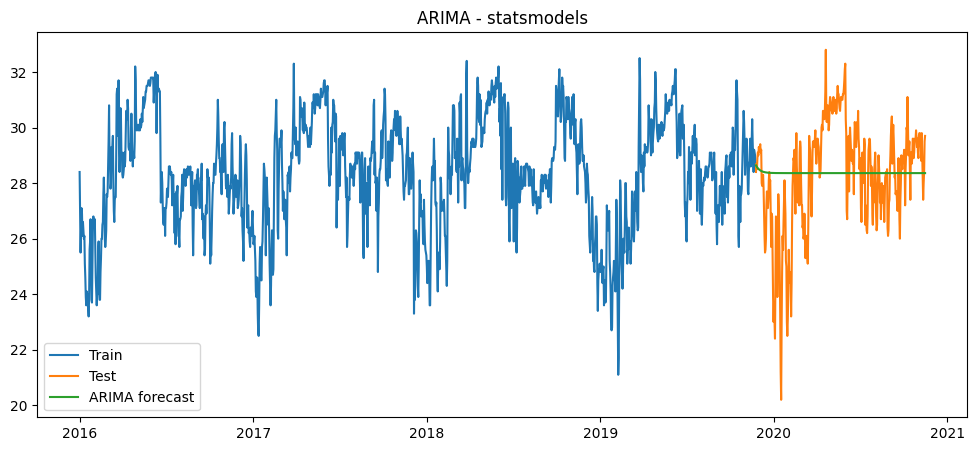

In [7]:
plt.figure(figsize=(12,5))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Test')
plt.plot(test.index, arima_forecast, label='ARIMA forecast')
plt.title('ARIMA - statsmodels')
plt.legend()
plt.show()

### Modelo con PMDARIMA

In [9]:
pm_model = pm.auto_arima(train, seasonal=False, stepwise=True, suppress_warnings=True)
pm_forecast = pm_model.predict(n_periods=len(test))

In [10]:
print("RMSE PMDARIMA:", np.sqrt(mean_squared_error(test, pm_forecast)))

RMSE PMDARIMA: 2.0031638859534877


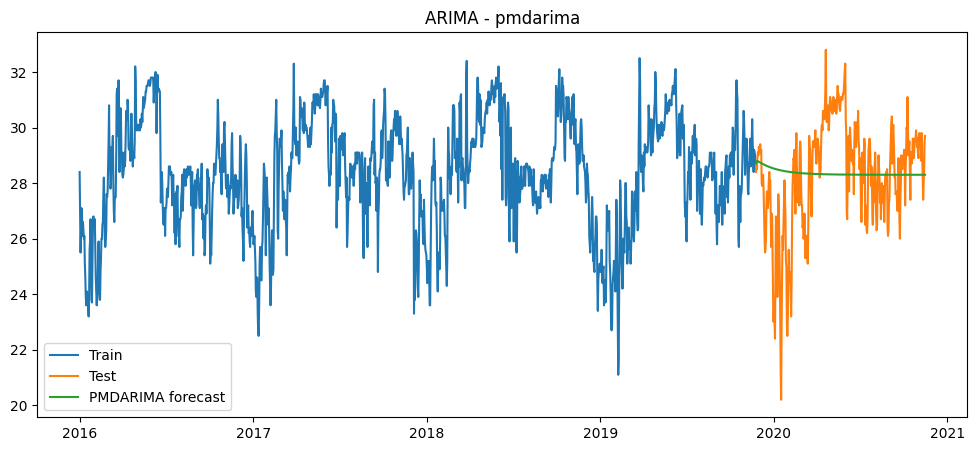

In [11]:
plt.figure(figsize=(12,5))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Test')
plt.plot(test.index, pm_forecast, label='PMDARIMA forecast')
plt.title('ARIMA - pmdarima')
plt.legend()
plt.show()

### Modelo 3: SkTime

In [ ]:
sktime_model = sktimeARIMA(order=(1,1,1) )
sktime_model.fit(y_train)
forecast3 = sktime_model.predict(fh=np.arange(1, len(y_test)+1))

In [13]:
prophet_model = Prophet(daily_seasonality=True)
prophet_model.fit(prophet_train)
future = prophet_model.make_future_dataframe(periods=len(test))
prophet_forecast = prophet_model.predict(future)

AttributeError: 'Prophet' object has no attribute 'stan_backend'